# Tópicos de aprendizaje supervisado

---

## 🎯 Objetivos académicos


1. **Aplicar técnicas de codificación de variables categóricas** (Label Encoding, One-Hot Encoding y Ordinal Encoding) y seleccionar la más adecuada según el modelo y el tipo de variable.
2. **Identificar y abordar problemas de desbalance de clases** en tareas de clasificación, utilizando estrategias como sobre-muestreo, submuestreo y ajuste de pesos.
3. **Evaluar el desempeño de modelos de clasificación y regresión** utilizando métricas apropiadas (accuracy, F1, ROC AUC, R², ECM, MAE) y comprender la importancia del escalado de variables en modelos

## Preparación del notebook
---

In [42]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.datasets import make_regression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Codificación de variables

Muchos modelos de aprendizaje automático no pueden trabajar directamente con variables categóricas (por ejemplo, el país o género de una persona). Estas deben transformarse a una representación numérica mediante un proceso conocido como **codificación**.

Distinguimos tres enfoques comunes:

1. **Label Encoding** – asigna un número entero a cada categoría. Útil para árboles de decisión, pero puede introducir un orden artificial.
2. **One-Hot Encoding** – crea una columna binaria por cada categoría. Es la opción preferida para modelos lineales o redes neuronales.
3. **Ordinal Encoding** – codifica categorías respetando un orden lógico (por ejemplo: Bajo < Medio < Alto).

---



### ⚙️ Ejemplo con datos sintéticos

Vamos a generar un dataset con `make_classification` y añadir columnas categóricas artificiales para simular un caso típico.

In [3]:
# 1. Generamos un dataset base
X, y = make_classification(n_samples=200, n_features=4, random_state=42)
df = pd.DataFrame(X, columns=["feature1", "feature2", "feature3", "feature4"])
df["target"] = y

# 2. Simulamos una variable categórica nominal (sin orden)
df["color"] = np.random.choice(["rojo", "verde", "azul"], size=len(df))

# 3. Simulamos una variable ordinal
df["nivel"] = np.random.choice(["bajo", "medio", "alto"], size=len(df), p=[0.3, 0.4, 0.3])

df.head()

,feature1,feature2,feature3,feature4,target,color,nivel
0,1.689767,-1.408241,-0.962936,1.163491,1,azul,medio
1,0.855820,-0.430646,-0.390659,0.435911,1,verde,medio
2,-1.175042,-1.447633,-0.163790,0.508040,0,verde,medio
3,1.394775,2.019333,0.297780,-0.766396,1,azul,alto
4,-0.073240,0.336417,0.136302,-0.199882,1,verde,bajo


---

### 🧪 Aplicamos diferentes codificaciones

#### 🔹 LabelEncoder (nominal)

In [4]:
le = LabelEncoder()
df["color_le"] = le.fit_transform(df["color"])
df[["color", "color_le"]].drop_duplicates()
df.head()

,feature1,feature2,feature3,feature4,target,color,nivel,color_le
0,1.689767,-1.408241,-0.962936,1.163491,1,azul,medio,0
1,0.855820,-0.430646,-0.390659,0.435911,1,verde,medio,2
2,-1.175042,-1.447633,-0.163790,0.508040,0,verde,medio,2
3,1.394775,2.019333,0.297780,-0.766396,1,azul,alto,0
4,-0.073240,0.336417,0.136302,-0.199882,1,verde,bajo,2



#### 🔹 OneHotEncoder (nominal)

In [5]:
# OneHotEncoder con drop para evitar colinealidad
ohe = OneHotEncoder(sparse_output=False, drop='first')
color_encoded = ohe.fit_transform(df[["color"]])

# Verificamos cuántas columnas se generaron
print(color_encoded.shape)  # Debe devolver (200, 2)

# Creamos el DataFrame con los nombres correctos
column_names = ohe.get_feature_names_out(["color"])  # Solo devolverá 2 columnas
df_ohe = pd.DataFrame(color_encoded, columns=column_names)

# Concatenamos
df = pd.concat([df, df_ohe], axis=1)
df.head()

(200, 2)


,feature1,feature2,feature3,feature4,target,color,nivel,color_le,color_rojo,color_verde
0,1.689767,-1.408241,-0.962936,1.163491,1,azul,medio,0,0.0,0.0
1,0.855820,-0.430646,-0.390659,0.435911,1,verde,medio,2,0.0,1.0
2,-1.175042,-1.447633,-0.163790,0.508040,0,verde,medio,2,0.0,1.0
3,1.394775,2.019333,0.297780,-0.766396,1,azul,alto,0,0.0,0.0
4,-0.073240,0.336417,0.136302,-0.199882,1,verde,bajo,2,0.0,1.0


#### 🔹 OrdinalEncoder (con orden definido)

In [6]:
orden_niveles = [["bajo", "medio", "alto"]]  # orden explícito
oe = OrdinalEncoder(categories=orden_niveles)
df["nivel_ord"] = oe.fit_transform(df[["nivel"]])
df[["nivel", "nivel_ord"]].drop_duplicates()
df.head()

,feature1,feature2,feature3,feature4,target,color,nivel,color_le,color_rojo,color_verde,nivel_ord
0,1.689767,-1.408241,-0.962936,1.163491,1,azul,medio,0,0.0,0.0,1.0
1,0.855820,-0.430646,-0.390659,0.435911,1,verde,medio,2,0.0,1.0,1.0
2,-1.175042,-1.447633,-0.163790,0.508040,0,verde,medio,2,0.0,1.0,1.0
3,1.394775,2.019333,0.297780,-0.766396,1,azul,alto,0,0.0,0.0,2.0
4,-0.073240,0.336417,0.136302,-0.199882,1,verde,bajo,2,0.0,1.0,0.0


### 💬 Preguntas para discusión

- ¿Qué diferencias encuentras entre `LabelEncoder` y `OneHotEncoder`?
- ¿Qué riesgos tiene usar `LabelEncoder` con modelos lineales?
- ¿Cómo afecta el orden en `OrdinalEncoder` al resultado?
- ¿Qué tipo de codificación usarías para árboles de decisión? ¿Y para regresión logística?


## ⚖️Clasificación desbalanceada

Un conjunto de datos está **desbalanceado** cuando una clase ocurre con mucha más frecuencia que otra. Esto es común en problemas como:

- Detección de fraude
- Diagnóstico médico
- Churn (cancelación de clientes)


En estos casos, un modelo puede parecer "bueno" solo porque predice siempre la clase mayoritaria, aunque ignore completamente la minoritaria.


---

### 🛠️ Estrategias para tratar el desbalance

1. **Sobre-muestreo**: aumentar la clase minoritaria (por ejemplo, con `SMOTE`)
2. **Submuestreo**: reducir la clase mayoritaria
3. **Uso de pesos en el modelo**: penalizar más los errores en la clase minoritaria (`class_weight='balanced'`)
4. **Métricas adaptadas**: usar métricas como F1 o ROC AUC en lugar de precisión (accuracy)

---
### 🧪 Generación de un dataset desbalanceado

In [83]:

# Dataset con 90% clase 0 y 10% clase 1
X, y = make_classification(n_samples=400,
                           n_features=15,
                           n_informative=10,
                           n_redundant=2,
                           n_repeated=1,
                           weights=[0.85, 0.15],
                           flip_y=0.01,
                           class_sep=0.7,
                           random_state=42)

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
df["target"] = y
df["target"].value_counts(normalize=True)

target
0    0.845
1    0.155
Name: proportion, dtype: float64


---

In [77]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

### 🧪 Regresión logística sin balanceo de clases

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        90
           1       0.67      0.20      0.31        10

    accuracy                           0.91       100
   macro avg       0.79      0.59      0.63       100
weighted avg       0.89      0.91      0.89       100



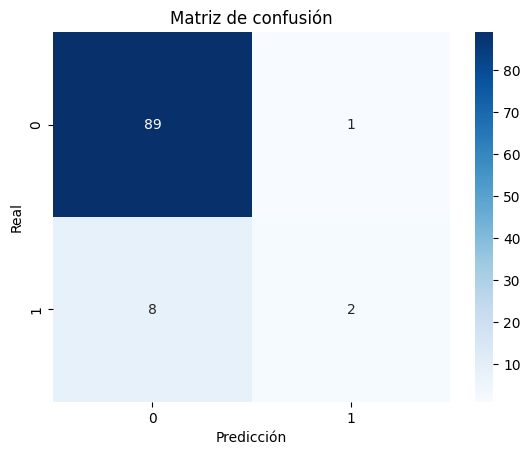

In [84]:


# Entrenamos el modelo
model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


# Reporte de métricas
print(classification_report(y_test, y_pred))



# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()



### 🧪 Regresión logística con balanceo de clases

              precision    recall  f1-score   support

           0       0.94      0.84      0.89        90
           1       0.26      0.50      0.34        10

    accuracy                           0.81       100
   macro avg       0.60      0.67      0.62       100
weighted avg       0.87      0.81      0.83       100



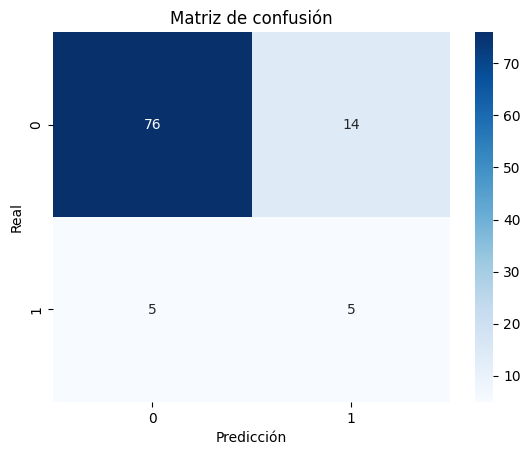

In [85]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {c:w for c, w in zip(classes, weights)}


# Entrenamos el modelo
model = LogisticRegression( class_weight=class_weight_dict, max_iter=1000,random_state=42)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


# Reporte de métricas
print(classification_report(y_test, y_pred))



# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

### 🌲🌳 Random Forest sin balanceo de clases



              precision    recall  f1-score   support

           0      0.900     1.000     0.947        90
           1      0.000     0.000     0.000        10

    accuracy                          0.900       100
   macro avg      0.450     0.500     0.474       100
weighted avg      0.810     0.900     0.853       100



c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

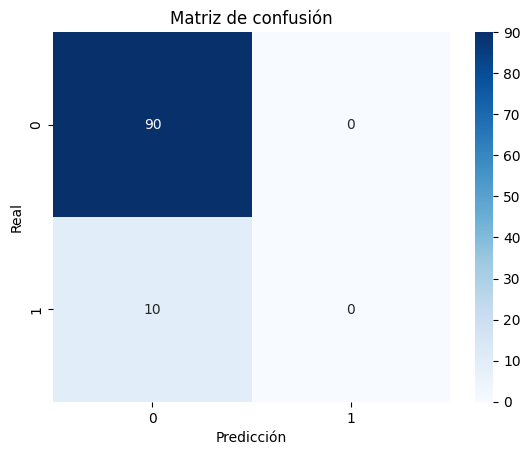

In [86]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))


# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

### 🌲🌳 Random Forest con balanceo de clases


              precision    recall  f1-score   support

           0      0.899     0.989     0.942        90
           1      0.000     0.000     0.000        10

    accuracy                          0.890       100
   macro avg      0.449     0.494     0.471       100
weighted avg      0.809     0.890     0.848       100



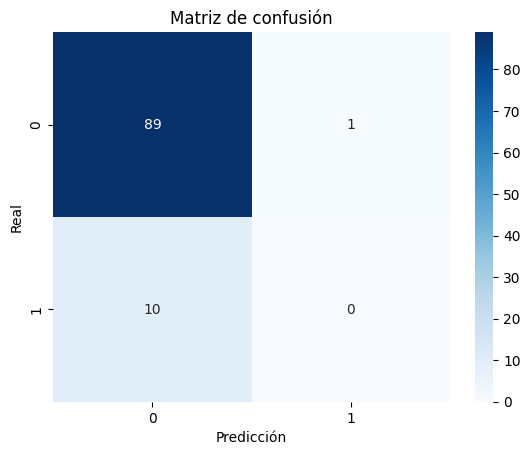

In [89]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))


# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

### 📈  Curva ROC

La curva ROC (*Receiver Operating Characteristic*) es una herramienta visual que evalúa el rendimiento de un clasificador binario al mostrar la relación entre la **tasa de verdaderos positivos (TPR)** y la **tasa de falsos positivos (FPR)** para distintos umbrales de decisión.


| Sigla | Nombre               | Significado                                |
|-------|----------------------|---------------------------------------------|
| TP    | Verdadero Positivo   | El modelo dijo "sí", y era "sí"             |
| FN    | Falso Negativo       | El modelo dijo "no", pero era "sí"          |
| FP    | Falso Positivo       | El modelo dijo "sí", pero era "no"          |
| TN    | Verdadero Negativo   | El modelo dijo "no", y era "no"             |



- En el eje **Y** se representa la **TPR** (también conocida como *recall*), que indica qué proporción de positivos reales el modelo logra capturar.
- En el eje **X** se representa la **FPR**, que muestra qué proporción de negativos reales el modelo clasifica erróneamente como positivos.

La curva ROC permite visualizar cómo cambia el rendimiento del modelo al variar el umbral de clasificación. Un modelo ideal se aproxima a la esquina superior izquierda (TPR = 1, FPR = 0). En cambio, un modelo aleatorio genera una línea diagonal (AUC ≈ 0.5).

El área bajo la curva (**AUC-ROC**) resume esta información en una sola métrica: **cuanto más cercana a 1, mejor la capacidad del modelo para discriminar entre clases**.

---

### 🧮 Fórmulas

- **TPR (Tasa de verdaderos positivos / Sensibilidad):**

$$
\text{TPR} = \frac{TP}{TP + FN}
$$

- **FPR (Tasa de falsos positivos):**

$$
\text{FPR} = \frac{FP}{FP + TN}
$$

Donde:

- **TP**: Verdaderos Positivos  
- **FN**: Falsos Negativos  
- **FP**: Falsos Positivos  
- **TN**: Verdaderos Negativos

<center>
  <img src="https://miro.medium.com/v2/resize:fit:1200/0*9h-FJb3PclpQDVQF.png" alt="IA para educación - Logo" style="max-width:80%; height:auto;"  width="25%">
</center>

### 📐 AUC Score

El **AUC score** (Área Bajo la Curva ROC) es una métrica que resume en un solo valor la capacidad de un modelo para distinguir entre clases. Su valor oscila entre **0.5** (modelo aleatorio) y **1.0** (modelo perfecto). Un AUC de **0.97**, como en este caso, indica que el modelo tiene una **muy alta probabilidad de asignar una mayor puntuación a los ejemplos positivos que a los negativos**, lo que refleja una excelente capacidad discriminativa sin depender de un umbral fijo.


In [ ]:
# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test, name='Regresion logística')
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


### 💬 Preguntas para discusión

- ¿Qué opinas del desempeño de este clasificador?

## Regresion

Cuando trabajamos con modelos de regresión (es decir, aquellos que predicen un valor numérico continuo), evaluamos su desempeño con métricas diferentes a las de clasificación.

Las tres métricas más comunes son:

- **R² (coeficiente de determinación):** mide qué proporción de la varianza de la variable dependiente puede explicar el modelo.
- **ECM (Error Cuadrático Medio):** penaliza más los errores grandes. Útil cuando los errores grandes son más costosos.
- **MAE (Error Absoluto Medio):** penaliza todos los errores por igual. Más robusto ante outliers.

---


In [ ]:
### ⚙️ Generación de datos sintéticos para regresión
# Dataset con ruido y sesgo
X, y = make_regression(n_samples=300,
                       n_features=3,
                       noise=15,
                       bias=100,
                       random_state=42)

df = pd.DataFrame(X, columns=["feature1", "feature2", "feature3"])
df["target"] = y
df.head()

Cuando usamos modelos como regresión lineal, es buena práctica **escalar las variables** para que todas tengan la misma unidad de medida. Esto es especialmente importante si las features están en diferentes escalas o si se planea usar regularización.


In [ ]:
### 🔄 Escalado de características
# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Escalado con media = 0 y desviación estándar = 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 💬 Preguntas para discusión

1. ¿Qué consecuencias podría tener entrenar un modelo de regresión sin escalar los datos si una de las variables es mucho mayor que las otras?

In [ ]:
### 📉 Entrenamiento y predicción con regresión lineal
# Entrenamiento
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)

In [ ]:
### 📏 Evaluación del modelo
# R^2
r2 = r2_score(y_test, y_pred)
print("R²:", round(r2, 3))

# ECM
ecm = mean_squared_error(y_test, y_pred)
print("ECM:", round(ecm, 2))

# MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", round(mae, 2))

## 📝 En Conclusión

---

1. **La correcta codificación de variables categóricas es esencial** para que los modelos de machine learning funcionen adecuadamente. Elegir entre Label Encoding, One-Hot Encoding u Ordinal Encoding depende del tipo de variable y del modelo utilizado.

2. **El desbalance de clases puede afectar gravemente el desempeño de los modelos de clasificación.** Es fundamental aplicar estrategias como sobre-muestreo, submuestreo, ajuste de pesos y el uso de métricas adecuadas (como F1 o ROC AUC) para evaluar correctamente los resultados.

3. **La evaluación de modelos debe hacerse con métricas apropiadas según el tipo de problema.** En clasificación se usan métricas como accuracy, F1 y AUC-ROC, mientras que en regresión se emplean R², ECM y MAE. Además, el escalado de variables es clave para modelos lineales y mejora la interpretación y el desempeño.

## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta el proyecto nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [Sprint 10](https://discord.com/channels/1081207584104656986/1270074586720899143).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal `#project` para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨